# Fila M/M/1 com falhas e reparos

**Disciplina:** TP 547 - Princípios de Simulação de Sistemas de Comunicação  
**Estudo de caso:** gateway de borda sujeito a falhas de processamento e reinicializações

Este notebook implementa uma simulação de eventos discretos com quatro eventos primários: chegada, partida, falha e reparo. Além do modelo principal, são executadas comparações com:

1. fila M/M/1 sem falhas;
2. fila M/M/2 sem falhas;
3. serviços exponencial, determinístico, Erlang-2 e hiperexponencial;
4. buffers infinito e finitos;
5. solução analítica aproximada por capacidade efetiva;
6. solução numérica da cadeia de Markov em tempo contínuo para o caso M/M/1 com falhas.

A estrutura segue o método de agendamento de eventos: o relógio avança diretamente para o evento iminente, as áreas estatísticas são atualizadas para o intervalo transcorrido e, em seguida, o estado do sistema é alterado.

## 1. Situação analisada e parâmetros

Considera-se um gateway que recebe lotes de dados de dispositivos IoT. Os lotes são armazenados em uma fila FIFO e processados por um único servidor lógico. O servidor pode falhar tanto ocioso quanto ocupado. Quando uma falha ocorre durante um atendimento, o lote permanece no servidor e o processamento é retomado após o reparo.

A unidade de tempo adotada é a hora:

- taxa de chegada: $\lambda=4{,}2$ lotes/h;
- taxa de serviço: $\mu=6$ lotes/h;
- taxa de falha: $\alpha=0{,}3$ falhas/h;
- taxa de reparo: $\beta=3$ reparos/h.

Logo:

$$E[T_a]=1/\lambda=14{,}29\text{ min},\quad E[T_s]=1/\mu=10\text{ min},$$

$$MTTF=1/\alpha=3{,}33\text{ h},\quad MTTR=1/\beta=20\text{ min}.$$

A disponibilidade do servidor é

$$A=\frac{\beta}{\alpha+\beta}=0{,}9091,$$

e a capacidade média de serviço é

$$\mu_{cap}=\mu A=5{,}4545\text{ lotes/h}.$$

A condição de estabilidade do sistema com buffer infinito é

$$\lambda < \mu\frac{\beta}{\alpha+\beta}.$$

In [1]:
# Bibliotecas usadas nos experimentos.
# numpy: geração de variáveis aleatórias e operações numéricas.
# pandas: organização das tabelas de resultados.
# matplotlib: construção dos gráficos.
# scipy.stats: intervalo de confiança t de Student.
# collections.deque: fila FIFO com remoção O(1) no início.
# dataclasses: estruturas simples para representar tarefas.

from dataclasses import dataclass
from collections import deque
from pathlib import Path
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t as student_t

# Diretórios usados para salvar tabelas e figuras.
BASE_DIR = Path.cwd()
FIG_DIR = BASE_DIR / "figuras_fila"
TAB_DIR = BASE_DIR / "tabelas_fila"
FIG_DIR.mkdir(exist_ok=True)
TAB_DIR.mkdir(exist_ok=True)

# Configuração visual uniforme para todos os gráficos.
plt.rcParams.update({
    "font.size": 10,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
})

# Parâmetros do cenário-base em unidades por hora.
LAMBDA_BASE = 4.2
MU_BASE = 6.0
ALPHA_BASE = 0.3
BETA_BASE = 3.0

# Configuração estatística.
N_REP_BASE = 20
N_REP_EXPERIMENTOS = 20
WARMUP = 100.0
TEMPO_COLETA = 1_000.0
CONFIANCA = 0.95
SEMENTE_MESTRA = 20260618

## 2. Modelo conceitual

### Variáveis de estado

- `n_sistema`: número total de lotes no sistema;
- `fila`: lista FIFO dos lotes que aguardam atendimento;
- `servidor_disponivel`: indica se o servidor está operacional;
- `tarefa_em_servico`: lote atualmente associado ao servidor;
- `tempo_restante`: parcela de serviço ainda necessária;
- `CLOCK`: relógio da simulação.

### Avisos da lista de eventos futuros

- `ta`: próxima chegada;
- `td`: próxima partida;
- `tf`: próxima falha;
- `tr`: término do reparo;
- `te`: término da simulação.

### Entidades, atributos, atividades e atrasos

- **Entidades:** lote de dados e servidor;
- **Atributos do lote:** instante de chegada, tempo de serviço requerido e tempo de serviço restante;
- **Lista:** fila FIFO;
- **Atividades:** intervalo entre chegadas, serviço, tempo até falha e reparo;
- **Atrasos:** espera na fila e interrupção durante reparo.

### Política de interrupção

Nos experimentos com distribuições não exponenciais é utilizada a política *preemptive-resume*: o tempo de serviço já executado não é perdido. Para a distribuição exponencial, essa política também é compatível com a propriedade de ausência de memória.

In [2]:
@dataclass
class Tarefa:
    """Representa um lote aceito pelo sistema."""
    chegada: float
    servico_total: float
    restante: float


def amostrar_servico(rng, mu, distribuicao):
    """
    Gera um tempo de serviço com média 1/mu.

    Distribuições disponíveis:
    - exponencial: coeficiente de variação igual a 1;
    - deterministico: variância nula;
    - erlang2: soma de duas exponenciais, CV² = 1/2;
    - hiperexponencial: mistura balanceada com CV² > 1.
    """
    if distribuicao == "exponencial":
        return rng.exponential(1.0 / mu)
    if distribuicao == "deterministico":
        return 1.0 / mu
    if distribuicao == "erlang2":
        # Cada fase possui taxa 2*mu; a soma das duas fases tem média 1/mu.
        return rng.gamma(shape=2.0, scale=1.0 / (2.0 * mu))
    if distribuicao == "hiperexponencial":
        # Mistura com p=0,5 e taxas mu/0,5 e mu/1,5.
        # As médias condicionais são 0,5/mu e 1,5/mu, mantendo média global 1/mu.
        if rng.random() < 0.5:
            return rng.exponential(0.5 / mu)
        return rng.exponential(1.5 / mu)
    raise ValueError(f"Distribuição de serviço desconhecida: {distribuicao}")


def simular_servidor_unico(
    lam,
    mu,
    alpha=0.0,
    beta=1.0,
    distribuicao="exponencial",
    capacidade=None,
    warmup=WARMUP,
    tempo_coleta=TEMPO_COLETA,
    seed=1,
):
    """
    Simula uma fila de servidor único por agendamento de eventos.

    Parâmetros
    ----------
    lam : taxa de chegada de Poisson.
    mu : inverso do tempo médio de serviço.
    alpha : taxa de falha enquanto o servidor está operacional.
    beta : taxa de reparo. Ignorado quando alpha=0.
    distribuicao : lei usada para o tempo de serviço.
    capacidade : número máximo de tarefas no sistema. None representa infinito.
    warmup : período inicial descartado.
    tempo_coleta : duração usada para formar as estimativas.
    seed : semente da replicação.

    Política de falha
    -----------------
    A falha pode ocorrer com o servidor livre ou ocupado. Se houver tarefa em serviço,
    o tempo processado até a falha é descontado e a tarefa permanece associada ao
    servidor. Depois do reparo, o atendimento continua a partir do tempo restante.
    """
    if lam <= 0 or mu <= 0 or alpha < 0 or beta <= 0:
        raise ValueError("As taxas devem respeitar lam>0, mu>0, alpha>=0 e beta>0.")
    if capacidade is not None and capacidade < 1:
        raise ValueError("A capacidade deve incluir ao menos uma posição de serviço.")
    if warmup < 0 or tempo_coleta <= 0:
        raise ValueError("warmup deve ser não negativo e tempo_coleta deve ser positivo.")

    rng = np.random.default_rng(seed)
    fim = warmup + tempo_coleta

    # Estado inicial: sistema vazio e servidor operacional.
    clock = 0.0
    fila = deque()
    tarefa_em_servico = None
    servidor_disponivel = True
    inicio_trecho_servico = None

    # Lista de eventos futuros representada pelas quatro variáveis de tempo.
    ta = rng.exponential(1.0 / lam)
    td = math.inf
    tf = rng.exponential(1.0 / alpha) if alpha > 0 else math.inf
    tr = math.inf

    # Acumuladores medidos somente depois do aquecimento.
    area_n = 0.0
    area_nq = 0.0
    tempo_ocupado = 0.0
    tempo_reparo = 0.0
    chegadas_observadas = 0
    aceitas_observadas = 0
    bloqueadas_observadas = 0
    partidas_observadas = 0
    soma_t_sistema = 0.0
    soma_t_fila = 0.0
    max_fila = 0

    def n_sistema():
        return len(fila) + (1 if tarefa_em_servico is not None else 0)

    def iniciar_ou_retomar_servico(instante):
        """Agenda a partida da tarefa associada ao servidor."""
        nonlocal td, inicio_trecho_servico
        if servidor_disponivel and tarefa_em_servico is not None:
            inicio_trecho_servico = instante
            td = instante + tarefa_em_servico.restante
        else:
            inicio_trecho_servico = None
            td = math.inf

    def retirar_da_fila(instante):
        """Move o primeiro lote da fila para o servidor e devolve seu tempo de espera."""
        nonlocal tarefa_em_servico
        tarefa_em_servico = fila.popleft()
        return instante - tarefa_em_servico.chegada

    while clock < fim:
        proximo = min(ta, td, tf, tr, fim)

        # Parte do intervalo [clock, proximo] que pertence à janela de coleta.
        inicio_valido = max(clock, warmup)
        fim_valido = min(proximo, fim)
        delta_valido = max(0.0, fim_valido - inicio_valido)

        # Estatísticas de tempo são integradas usando o estado que permaneceu constante
        # entre o evento anterior e o evento atual.
        if delta_valido > 0:
            area_n += n_sistema() * delta_valido
            area_nq += len(fila) * delta_valido
            if servidor_disponivel and tarefa_em_servico is not None:
                tempo_ocupado += delta_valido
            if not servidor_disponivel:
                tempo_reparo += delta_valido

        clock = proximo
        if clock >= fim:
            break

        if proximo == ta:
            # EVENTO DE CHEGADA
            ta = clock + rng.exponential(1.0 / lam)
            observada = clock >= warmup
            if observada:
                chegadas_observadas += 1

            lotado = capacidade is not None and n_sistema() >= capacidade
            if lotado:
                if observada:
                    bloqueadas_observadas += 1
                continue

            servico = amostrar_servico(rng, mu, distribuicao)
            nova = Tarefa(chegada=clock, servico_total=servico, restante=servico)
            if observada:
                aceitas_observadas += 1

            if servidor_disponivel and tarefa_em_servico is None:
                tarefa_em_servico = nova
                iniciar_ou_retomar_servico(clock)
            else:
                fila.append(nova)
                max_fila = max(max_fila, len(fila))

        elif proximo == td:
            # EVENTO DE PARTIDA
            concluida = tarefa_em_servico
            tarefa_em_servico = None
            td = math.inf
            inicio_trecho_servico = None

            if concluida.chegada >= warmup:
                partidas_observadas += 1
                soma_t_sistema += clock - concluida.chegada

            if fila:
                espera = retirar_da_fila(clock)
                if tarefa_em_servico.chegada >= warmup:
                    soma_t_fila += espera
                iniciar_ou_retomar_servico(clock)

        elif proximo == tf:
            # EVENTO DE FALHA
            # Se o servidor estava processando, desconta-se o trecho executado desde
            # a última retomada. O aviso de partida é cancelado durante o reparo.
            if tarefa_em_servico is not None and inicio_trecho_servico is not None:
                processado = clock - inicio_trecho_servico
                tarefa_em_servico.restante = max(0.0, tarefa_em_servico.restante - processado)
            servidor_disponivel = False
            inicio_trecho_servico = None
            td = math.inf
            tf = math.inf
            tr = clock + rng.exponential(1.0 / beta)

        else:
            # EVENTO DE REPARO
            servidor_disponivel = True
            tr = math.inf
            tf = clock + rng.exponential(1.0 / alpha) if alpha > 0 else math.inf

            # Se não havia tarefa interrompida, a primeira tarefa da fila passa ao servidor.
            if tarefa_em_servico is None and fila:
                espera = retirar_da_fila(clock)
                if tarefa_em_servico.chegada >= warmup:
                    soma_t_fila += espera
            iniciar_ou_retomar_servico(clock)

    # Métricas temporais.
    e_n = area_n / tempo_coleta
    e_nq = area_nq / tempo_coleta
    utilizacao = tempo_ocupado / tempo_coleta
    p_down = tempo_reparo / tempo_coleta
    disponibilidade = 1.0 - p_down
    vazao = partidas_observadas / tempo_coleta
    prob_bloqueio = (bloqueadas_observadas / chegadas_observadas
                     if chegadas_observadas else 0.0)

    # A Lei de Little é aplicada com a vazão observada. As médias por tarefa também são
    # calculadas como controle independente quando há partidas suficientes.
    e_t_little = e_n / vazao if vazao > 0 else math.inf
    e_tq_little = e_nq / vazao if vazao > 0 else math.inf
    e_t_amostra = soma_t_sistema / partidas_observadas if partidas_observadas else math.nan
    e_tq_amostra = soma_t_fila / partidas_observadas if partidas_observadas else math.nan

    return {
        "E_N": e_n,
        "E_Nq": e_nq,
        "E_T": e_t_little,
        "E_Tq": e_tq_little,
        "E_T_amostra": e_t_amostra,
        "E_Tq_amostra": e_tq_amostra,
        "utilizacao": utilizacao,
        "P_down": p_down,
        "disponibilidade": disponibilidade,
        "vazao": vazao,
        "prob_bloqueio": prob_bloqueio,
        "chegadas": chegadas_observadas,
        "aceitas": aceitas_observadas,
        "partidas": partidas_observadas,
        "max_fila": max_fila,
    }

## 3. Modelo auxiliar M/M/m sem falhas

A comparação com múltiplos servidores utiliza uma fila M/M/m, buffer infinito e disciplina FIFO. A implementação mantém um vetor com os tempos das próximas partidas. A chegada ocupa imediatamente um servidor livre; caso todos estejam ocupados, a tarefa entra na fila.

In [3]:
def simular_mmm(lam, mu, m, warmup=WARMUP, tempo_coleta=TEMPO_COLETA, seed=1):
    """Simula uma fila M/M/m confiável com buffer infinito e disciplina FIFO."""
    if m < 1:
        raise ValueError("m deve ser inteiro positivo.")
    rng = np.random.default_rng(seed)
    fim = warmup + tempo_coleta
    clock = 0.0
    ta = rng.exponential(1.0 / lam)
    partidas = [math.inf] * m
    chegadas_servidor = [None] * m
    fila = deque()

    area_n = area_nq = tempo_ocupado_total = 0.0
    saidas = 0

    while clock < fim:
        td = min(partidas)
        indice_td = int(np.argmin(partidas))
        proximo = min(ta, td, fim)
        inicio_valido = max(clock, warmup)
        fim_valido = min(proximo, fim)
        delta = max(0.0, fim_valido - inicio_valido)
        if delta > 0:
            ocupados = sum(np.isfinite(partidas))
            area_n += (len(fila) + ocupados) * delta
            area_nq += len(fila) * delta
            tempo_ocupado_total += ocupados * delta
        clock = proximo
        if clock >= fim:
            break

        if proximo == ta:
            ta = clock + rng.exponential(1.0 / lam)
            livres = [i for i, x in enumerate(partidas) if not np.isfinite(x)]
            if livres:
                i = livres[0]
                chegadas_servidor[i] = clock
                partidas[i] = clock + rng.exponential(1.0 / mu)
            else:
                fila.append(clock)
        else:
            if chegadas_servidor[indice_td] is not None and chegadas_servidor[indice_td] >= warmup:
                saidas += 1
            partidas[indice_td] = math.inf
            chegadas_servidor[indice_td] = None
            if fila:
                chegada = fila.popleft()
                chegadas_servidor[indice_td] = chegada
                partidas[indice_td] = clock + rng.exponential(1.0 / mu)

    vazao = saidas / tempo_coleta
    e_n = area_n / tempo_coleta
    e_nq = area_nq / tempo_coleta
    return {
        "E_N": e_n,
        "E_Nq": e_nq,
        "E_T": e_n / vazao,
        "E_Tq": e_nq / vazao,
        "utilizacao": tempo_ocupado_total / (m * tempo_coleta),
        "vazao": vazao,
        "P_down": 0.0,
        "disponibilidade": 1.0,
        "prob_bloqueio": 0.0,
    }

## 4. Referências analíticas e tratamento estatístico

A aproximação por capacidade efetiva utiliza

$$\mu_{eff}=\mu\frac{\beta}{\alpha+\beta}.$$

A disponibilidade e a capacidade média são exatas para o processo alternante exponencial. O uso das fórmulas usuais da M/M/1 com $\mu_{eff}$ é apenas uma aproximação para ocupação e atraso, pois as interrupções aumentam a variabilidade do serviço percebido.

A solução numérica da cadeia de Markov em tempo contínuo é obtida truncando o número de tarefas em $N_{max}$, construindo a matriz geradora dos estados $(n,U)$ e $(n,D)$ e resolvendo

$$\boldsymbol{\pi}Q=0,\qquad \boldsymbol{\pi}\mathbf{1}=1.$$

Cada experimento é executado em replicações independentes. A semilargura do intervalo de confiança é

$$h=t_{1-\gamma/2,\,r-1}\frac{s}{\sqrt{r}}.$$

In [4]:
def aproximacao_taxa_efetiva(lam, mu, alpha, beta):
    """Retorna as fórmulas da M/M/1 usando a capacidade média mu*beta/(alpha+beta)."""
    disponibilidade = beta / (alpha + beta) if alpha > 0 else 1.0
    mu_eff = mu * disponibilidade
    rho = lam / mu_eff
    if rho >= 1:
        return {"estavel": False, "A": disponibilidade, "mu_eff": mu_eff, "rho": rho}
    return {
        "estavel": True,
        "A": disponibilidade,
        "mu_eff": mu_eff,
        "rho": rho,
        "E_N": rho / (1.0 - rho),
        "E_Nq": rho**2 / (1.0 - rho),
        "E_T": 1.0 / (mu_eff - lam),
        "E_Tq": rho / (mu_eff - lam),
        "P_down": 1.0 - disponibilidade,
    }


def solucao_ctmc(lam, mu, alpha, beta, n_max=100):
    """
    Resolve numericamente a CTMC da fila M/M/1 com falhas.

    Estado 2*n: servidor operacional com n tarefas.
    Estado 2*n+1: servidor em reparo com n tarefas.
    A truncagem é aceita quando a probabilidade no último nível é desprezível.
    """
    tamanho = 2 * (n_max + 1)
    Q = np.zeros((tamanho, tamanho), dtype=float)

    def up(n): return 2 * n
    def down(n): return 2 * n + 1

    for n in range(n_max + 1):
        # Chegadas mantêm o estado operacional/reparo e elevam o nível.
        if n < n_max:
            Q[up(n), up(n + 1)] += lam
            Q[down(n), down(n + 1)] += lam
        # Serviço somente no estado operacional e com pelo menos uma tarefa.
        if n > 0:
            Q[up(n), up(n - 1)] += mu
        # Falha e reparo não alteram o número de tarefas.
        Q[up(n), down(n)] += alpha
        Q[down(n), up(n)] += beta

    # Diagonal da matriz geradora: negativo da soma das taxas de saída.
    for i in range(tamanho):
        Q[i, i] = -np.sum(Q[i, :])

    # Substitui uma equação de equilíbrio pela normalização das probabilidades.
    A = Q.T.copy()
    b = np.zeros(tamanho)
    A[-1, :] = 1.0
    b[-1] = 1.0
    pi = np.linalg.solve(A, b)

    niveis = np.arange(n_max + 1)
    p_n = pi[0::2] + pi[1::2]
    e_n = float(np.sum(niveis * p_n))
    p_down = float(np.sum(pi[1::2]))
    vazao = mu * float(np.sum(pi[2::2]))  # estados operacionais n>=1
    e_nq = e_n - vazao / mu
    return {
        "E_N": e_n,
        "E_Nq": e_nq,
        "E_T": e_n / vazao,
        "E_Tq": e_nq / vazao,
        "P_down": p_down,
        "disponibilidade": 1.0 - p_down,
        "vazao": vazao,
        "massa_borda": float(p_n[-1]),
    }


def resumir_replicacoes(resultados, confianca=CONFIANCA):
    """Calcula média, desvio amostral e semilargura do IC t de Student."""
    linhas = []
    chaves = [k for k, v in resultados[0].items() if isinstance(v, (int, float, np.floating))]
    r = len(resultados)
    tcrit = student_t.ppf(0.5 + confianca / 2.0, df=r - 1)
    for chave in chaves:
        valores = np.array([x[chave] for x in resultados], dtype=float)
        valores = valores[np.isfinite(valores)]
        if len(valores) < 2:
            continue
        media = float(np.mean(valores))
        desvio = float(np.std(valores, ddof=1))
        semi_ic = float(tcrit * desvio / np.sqrt(len(valores)))
        linhas.append({"metrica": chave, "media": media, "desvio": desvio, "semi_ic_95": semi_ic})
    return pd.DataFrame(linhas)


def executar_replicacoes(funcao, n_rep, semente_mestra, **kwargs):
    """Executa replicações independentes usando sementes derivadas de SeedSequence."""
    sementes = np.random.SeedSequence(semente_mestra).spawn(n_rep)
    resultados = []
    for seq in sementes:
        seed = int(seq.generate_state(1)[0])
        resultados.append(funcao(seed=seed, **kwargs))
    return resultados


def media_ic(resultados, metrica):
    """Atalho para obter média e semilargura do IC95 de uma métrica."""
    tabela = resumir_replicacoes(resultados)
    linha = tabela.loc[tabela["metrica"] == metrica].iloc[0]
    return float(linha["media"]), float(linha["semi_ic_95"])

## 5. Validação do simulador

São executadas três verificações:

1. M/M/1 sem falhas contra as fórmulas exatas;
2. disponibilidade simulada contra $\beta/(\alpha+\beta)$;
3. cenário-base contra a solução numérica da CTMC.

In [5]:
# Validação 1: fila M/M/1 confiável.
rep_sem_falha = executar_replicacoes(
    simular_servidor_unico,
    N_REP_BASE,
    SEMENTE_MESTRA,
    lam=LAMBDA_BASE,
    mu=MU_BASE,
    alpha=0.0,
    beta=BETA_BASE,
    distribuicao="exponencial",
)

rho_mm1 = LAMBDA_BASE / MU_BASE
teorico_mm1 = {
    "E_N": rho_mm1 / (1.0 - rho_mm1),
    "E_Nq": rho_mm1**2 / (1.0 - rho_mm1),
    "E_T": 1.0 / (MU_BASE - LAMBDA_BASE),
    "E_Tq": rho_mm1 / (MU_BASE - LAMBDA_BASE),
}

# Validação 2 e 3: modelo com falhas.
rep_base = executar_replicacoes(
    simular_servidor_unico,
    N_REP_BASE,
    SEMENTE_MESTRA + 1000,
    lam=LAMBDA_BASE,
    mu=MU_BASE,
    alpha=ALPHA_BASE,
    beta=BETA_BASE,
    distribuicao="exponencial",
)
ctmc_base = solucao_ctmc(LAMBDA_BASE, MU_BASE, ALPHA_BASE, BETA_BASE)
aprx_base = aproximacao_taxa_efetiva(LAMBDA_BASE, MU_BASE, ALPHA_BASE, BETA_BASE)

linhas = []
for metrica in ["E_N", "E_Nq", "E_T", "E_Tq"]:
    media_sf, ic_sf = media_ic(rep_sem_falha, metrica)
    media_cf, ic_cf = media_ic(rep_base, metrica)
    linhas.append({
        "Métrica": metrica,
        "M/M/1 sim.": media_sf,
        "IC95 M/M/1": ic_sf,
        "M/M/1 teórico": teorico_mm1[metrica],
        "Falhas sim.": media_cf,
        "IC95 falhas": ic_cf,
        "CTMC": ctmc_base[metrica],
        "Aprox. μ_eff": aprx_base[metrica],
    })

tabela_validacao = pd.DataFrame(linhas)
tabela_validacao.to_csv(TAB_DIR / "validacao.csv", index=False)
tabela_validacao.round(4)

,Métrica,M/M/1 sim.,IC95 M/M/1,M/M/1 teórico,Falhas sim.,IC95 falhas,CTMC,Aprox. μ_eff
0,E_N,2.4116,0.1141,2.3333,3.8859,0.4275,3.9012,3.3478
1,E_Nq,1.7094,0.1091,1.6333,3.1199,0.4194,3.2012,2.5778
2,E_T,0.5750,0.0254,0.5556,0.9282,0.0968,0.9289,0.7971
3,E_Tq,0.4075,0.0248,0.3889,0.7449,0.0957,0.7622,0.6138


In [6]:
# Tabela complementar de disponibilidade, utilização e vazão.
metricas_operacionais = []
for metrica in ["disponibilidade", "P_down", "utilizacao", "vazao"]:
    media, ic = media_ic(rep_base, metrica)
    referencia = ctmc_base.get(metrica, np.nan)
    metricas_operacionais.append({
        "Métrica": metrica,
        "Simulação": media,
        "IC95": ic,
        "Referência CTMC": referencia,
    })
tabela_operacional = pd.DataFrame(metricas_operacionais)
tabela_operacional.to_csv(TAB_DIR / "cenario_base_operacional.csv", index=False)
tabela_operacional.round(5)

,Métrica,Simulação,IC95,Referência CTMC
0,disponibilidade,0.90941,0.00397,0.90909
1,P_down,0.09059,0.00397,0.09091
2,utilizacao,0.69605,0.00761,NaN
3,vazao,4.17890,0.03460,4.20000


## 6. Experimento paramétrico: chegada, serviço, falha e reparo

Cada ponto é a média de 20 replicações independentes e possui intervalo de confiança de 95%. Pontos que violam a condição de estabilidade do sistema com buffer infinito não são simulados.

In [7]:
def varredura_parametro(nome, valores):
    """Executa a varredura de um parâmetro do cenário-base."""
    linhas = []
    for j, valor in enumerate(valores):
        pars = dict(lam=LAMBDA_BASE, mu=MU_BASE, alpha=ALPHA_BASE, beta=BETA_BASE)
        pars[nome] = float(valor)
        cap_media = pars["mu"] * pars["beta"] / (pars["alpha"] + pars["beta"])
        if pars["lam"] >= cap_media:
            continue
        reps = executar_replicacoes(
            simular_servidor_unico,
            N_REP_EXPERIMENTOS,
            SEMENTE_MESTRA + 10_000 + j + hash(nome) % 1000,
            **pars,
            distribuicao="exponencial",
        )
        aprx = aproximacao_taxa_efetiva(**pars)
        linha = {nome: valor, "rho_eff": pars["lam"] / cap_media}
        for metrica in ["E_N", "E_T"]:
            media, ic = media_ic(reps, metrica)
            linha[f"{metrica}_sim"] = media
            linha[f"{metrica}_ic"] = ic
            linha[f"{metrica}_aprx"] = aprx[metrica]
        linhas.append(linha)
    return pd.DataFrame(linhas)

varreduras = {
    "lam": np.linspace(1.0, 5.0, 6),
    "mu": np.linspace(5.0, 10.0, 6),
    "alpha": np.linspace(0.05, 0.95, 6),
    "beta": np.linspace(0.6, 6.0, 6),
}

resultados_varredura = {}
for nome, valores in varreduras.items():
    df = varredura_parametro(nome, valores)
    df.to_csv(TAB_DIR / f"varredura_{nome}.csv", index=False)
    resultados_varredura[nome] = df

resultados_varredura["lam"].round(4)

,lam,rho_eff,E_N_sim,E_N_ic,E_N_aprx,E_T_sim,E_T_ic,E_T_aprx
0,1.0,0.1833,0.2607,0.0076,0.2245,0.2606,0.0063,0.2245
1,1.8,0.3300,0.5774,0.0232,0.4925,0.3230,0.0108,0.2736
2,2.6,0.4767,1.0572,0.0280,0.9108,0.4059,0.0102,0.3503
3,3.4,0.6233,1.9613,0.0856,1.6549,0.5747,0.0237,0.4867
4,4.2,0.7700,3.6833,0.2264,3.3478,0.8792,0.0494,0.7971
5,5.0,0.9167,12.7609,1.6856,11.0000,2.5626,0.3323,2.2000


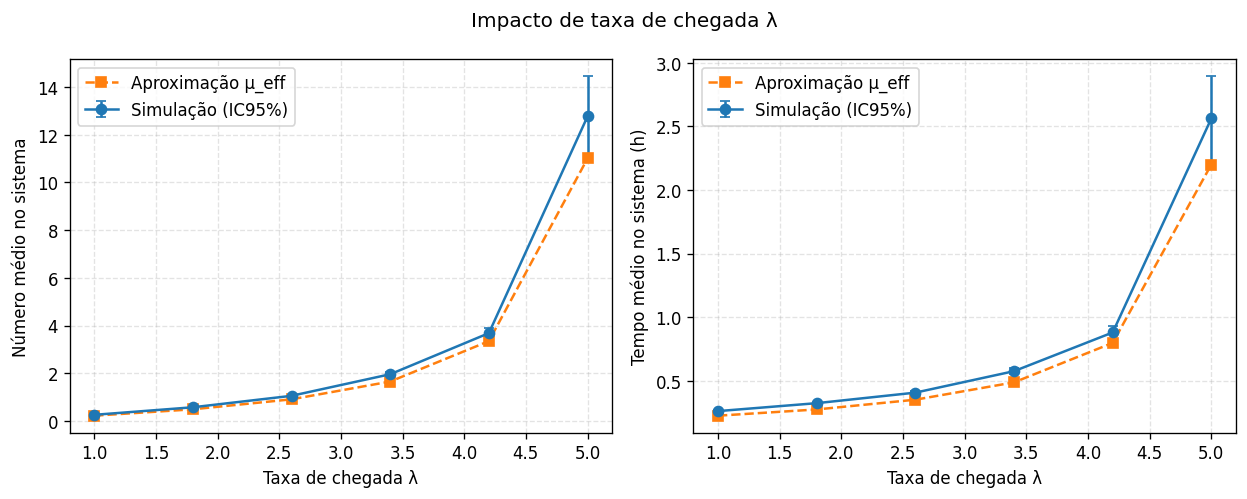

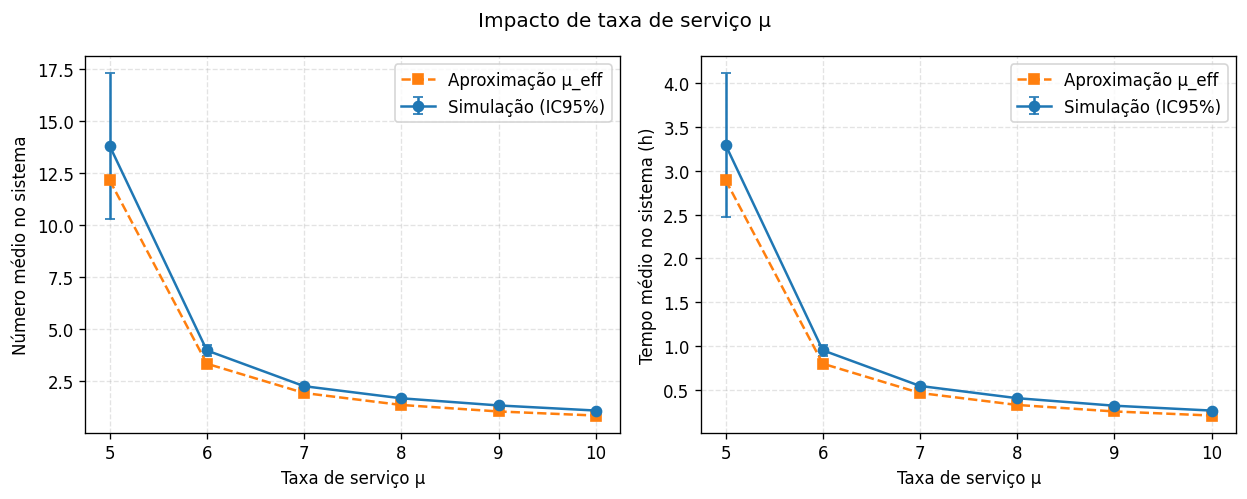

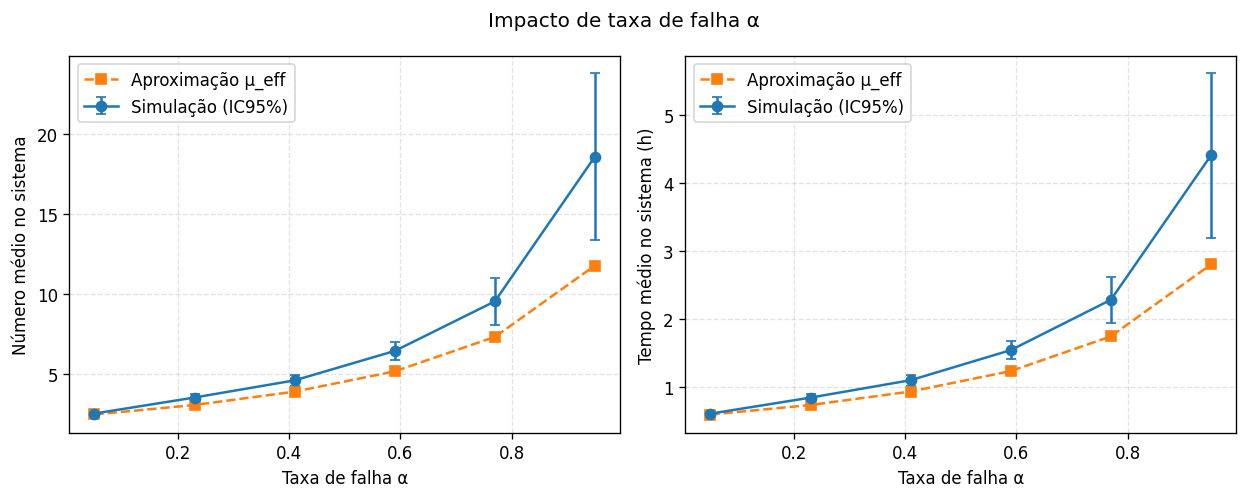

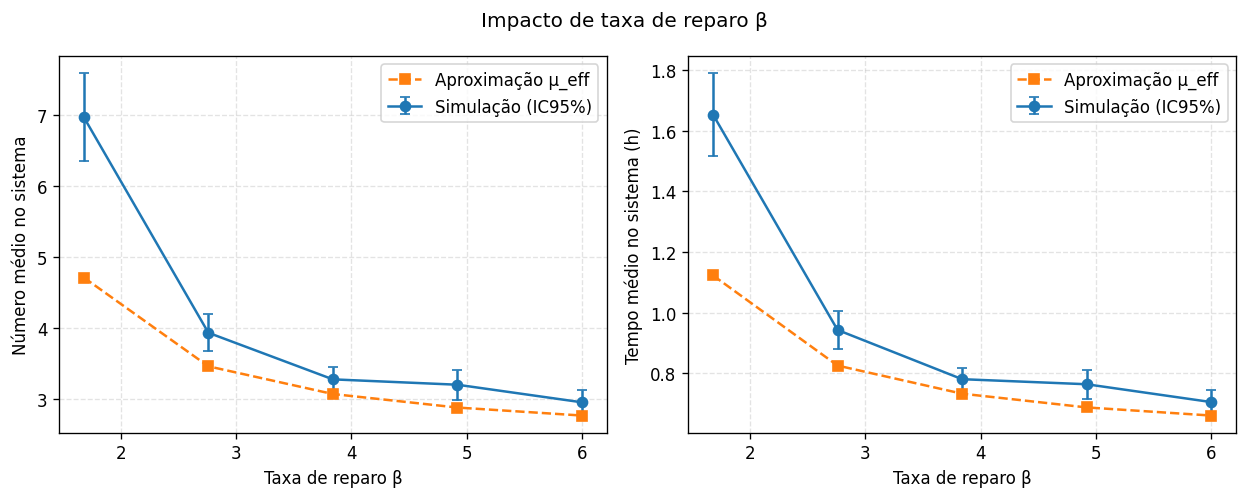

In [8]:
# Um gráfico por parâmetro, com E[N] à esquerda e E[T] à direita.
rotulos = {"lam": "Taxa de chegada λ", "mu": "Taxa de serviço μ",
           "alpha": "Taxa de falha α", "beta": "Taxa de reparo β"}

for nome, df in resultados_varredura.items():
    x = df[nome]
    fig, eixos = plt.subplots(1, 2, figsize=(10.5, 4.2))
    for ax, metrica, ylabel in zip(eixos, ["E_N", "E_T"],
                                   ["Número médio no sistema", "Tempo médio no sistema (h)"]):
        ax.errorbar(x, df[f"{metrica}_sim"], yerr=df[f"{metrica}_ic"],
                    marker="o", capsize=3, label="Simulação (IC95%)")
        ax.plot(x, df[f"{metrica}_aprx"], marker="s", linestyle="--", label="Aproximação μ_eff")
        ax.set_xlabel(rotulos[nome])
        ax.set_ylabel(ylabel)
        ax.legend()
    fig.suptitle(f"Impacto de {rotulos[nome].lower()}")
    fig.tight_layout()
    fig.savefig(FIG_DIR / f"varredura_{nome}.png")
    plt.show()

## 7. Comparação com outros tipos de fila

A comparação usa a mesma chegada e o mesmo tempo médio de serviço:

- M/M/1 confiável;
- M/M/1 com falhas e reparos;
- M/M/2 confiável.

A fila M/M/2 representa redundância de capacidade. Como cada servidor mantém taxa $\mu$, sua capacidade total é maior que a do sistema de servidor único; a comparação evidencia o efeito de adicionar recurso e não pretende impor custo equivalente.

In [9]:
comparacoes = []

reps_mm1 = executar_replicacoes(
    simular_servidor_unico, N_REP_BASE, SEMENTE_MESTRA + 20_000,
    lam=LAMBDA_BASE, mu=MU_BASE, alpha=0.0, beta=BETA_BASE,
    distribuicao="exponencial")
reps_falha = executar_replicacoes(
    simular_servidor_unico, N_REP_BASE, SEMENTE_MESTRA + 21_000,
    lam=LAMBDA_BASE, mu=MU_BASE, alpha=ALPHA_BASE, beta=BETA_BASE,
    distribuicao="exponencial")
reps_mm2 = executar_replicacoes(
    simular_mmm, N_REP_BASE, SEMENTE_MESTRA + 22_000,
    lam=LAMBDA_BASE, mu=MU_BASE, m=2)

for nome, reps in [("M/M/1 sem falhas", reps_mm1),
                   ("M/M/1 com falhas", reps_falha),
                   ("M/M/2 sem falhas", reps_mm2)]:
    linha = {"Sistema": nome}
    for metrica in ["E_N", "E_Nq", "E_T", "E_Tq", "utilizacao", "vazao"]:
        media, ic = media_ic(reps, metrica)
        linha[metrica] = media
        linha[f"IC_{metrica}"] = ic
    comparacoes.append(linha)

tabela_filas = pd.DataFrame(comparacoes)
tabela_filas.to_csv(TAB_DIR / "comparacao_filas.csv", index=False)
tabela_filas.round(4)

,Sistema,E_N,IC_E_N,E_Nq,IC_E_Nq,E_T,IC_E_T,E_Tq,IC_E_Tq,utilizacao,IC_utilizacao,vazao,IC_vazao
0,M/M/1 sem falhas,2.2884,0.0777,1.5929,0.0719,0.5460,0.0171,0.3800,0.0162,0.6955,0.0074,4.1902,0.0279
1,M/M/1 com falhas,3.9703,0.2598,3.1991,0.2561,0.9403,0.0609,0.7576,0.0601,0.7031,0.0066,4.2218,0.0246
2,M/M/2 sem falhas,0.7947,0.0090,0.0971,0.0041,0.1902,0.0018,0.0232,0.0009,0.3488,0.0029,4.1779,0.0279


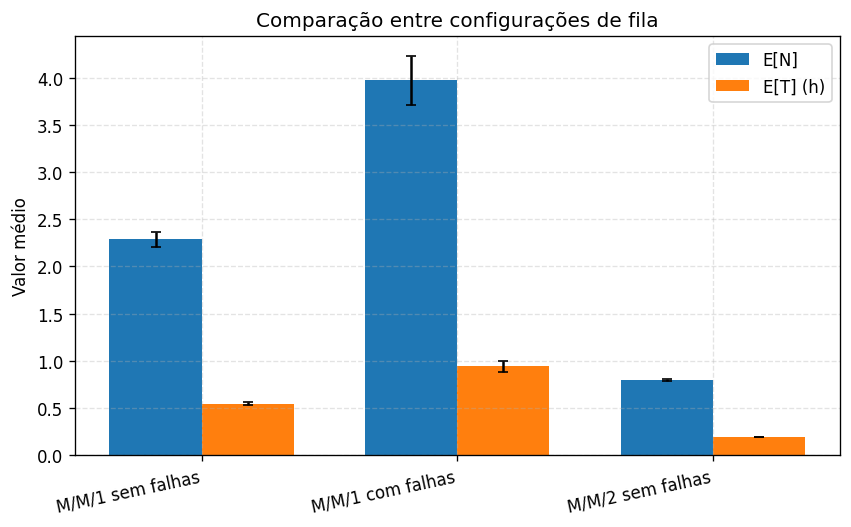

In [10]:
fig, ax = plt.subplots(figsize=(7.2, 4.5))
x = np.arange(len(tabela_filas))
ax.bar(x - 0.18, tabela_filas["E_N"], width=0.36, yerr=tabela_filas["IC_E_N"],
       capsize=3, label="E[N]")
ax.bar(x + 0.18, tabela_filas["E_T"], width=0.36, yerr=tabela_filas["IC_E_T"],
       capsize=3, label="E[T] (h)")
ax.set_xticks(x)
ax.set_xticklabels(tabela_filas["Sistema"], rotation=12, ha="right")
ax.set_ylabel("Valor médio")
ax.set_title("Comparação entre configurações de fila")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "comparacao_filas.png")
plt.show()

## 8. Comparação das distribuições de serviço

As quatro distribuições possuem a mesma média $1/\mu$. A diferença está na variabilidade. Mantêm-se as mesmas taxas de chegada, falha e reparo, e a política de retomada preserva o trabalho já executado.

In [11]:
distribuicoes = ["deterministico", "erlang2", "exponencial", "hiperexponencial"]
nomes_dist = {
    "deterministico": "Determinístico",
    "erlang2": "Erlang-2",
    "exponencial": "Exponencial",
    "hiperexponencial": "Hiperexponencial",
}
linhas_dist = []
for j, dist in enumerate(distribuicoes):
    reps = executar_replicacoes(
        simular_servidor_unico, N_REP_EXPERIMENTOS, SEMENTE_MESTRA + 30_000 + j,
        lam=LAMBDA_BASE, mu=MU_BASE, alpha=ALPHA_BASE, beta=BETA_BASE,
        distribuicao=dist)
    linha = {"Distribuição": nomes_dist[dist]}
    for metrica in ["E_N", "E_Nq", "E_T", "E_Tq", "vazao"]:
        media, ic = media_ic(reps, metrica)
        linha[metrica] = media
        linha[f"IC_{metrica}"] = ic
    linhas_dist.append(linha)

tabela_distribuicoes = pd.DataFrame(linhas_dist)
tabela_distribuicoes.to_csv(TAB_DIR / "comparacao_distribuicoes.csv", index=False)
tabela_distribuicoes.round(4)

,Distribuição,E_N,IC_E_N,E_Nq,IC_E_Nq,E_T,IC_E_T,E_Tq,IC_E_Tq,vazao,IC_vazao
0,Determinístico,2.6604,0.0858,1.8919,0.0832,0.6366,0.0187,0.4527,0.0186,4.1779,0.0260
1,Erlang-2,3.2744,0.2307,2.5043,0.2242,0.7821,0.0529,0.5980,0.0519,4.1844,0.0352
2,Exponencial,3.7148,0.2675,2.9496,0.2579,0.8887,0.0621,0.7055,0.0602,4.1778,0.0278
3,Hiperexponencial,4.6137,0.3012,3.8426,0.2961,1.1032,0.0712,0.9188,0.0700,4.1822,0.0278


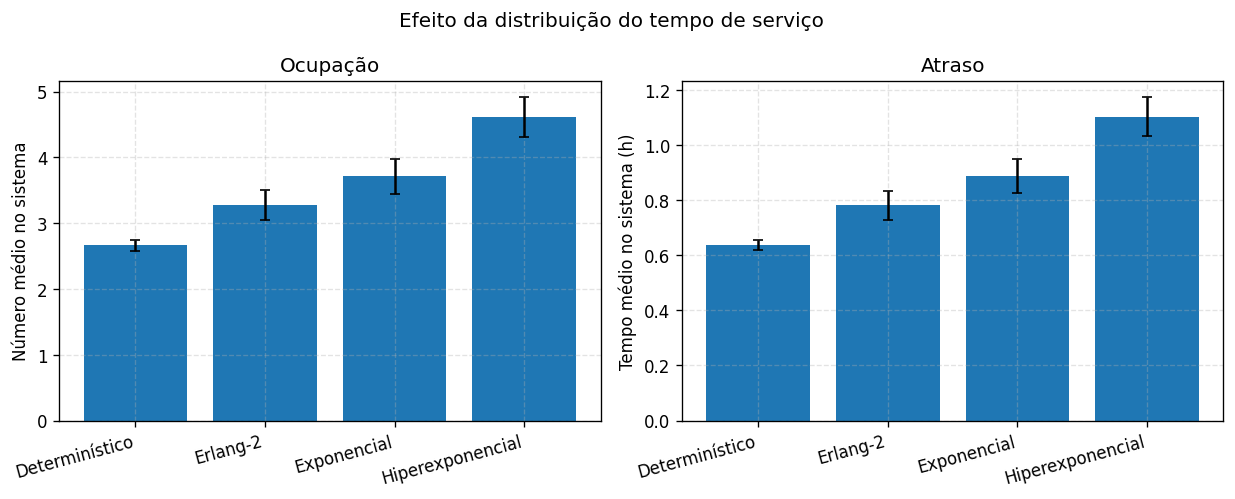

In [12]:
fig, eixos = plt.subplots(1, 2, figsize=(10.5, 4.2))
x = np.arange(len(tabela_distribuicoes))
eixos[0].bar(x, tabela_distribuicoes["E_N"], yerr=tabela_distribuicoes["IC_E_N"], capsize=3)
eixos[0].set_ylabel("Número médio no sistema")
eixos[0].set_title("Ocupação")
eixos[1].bar(x, tabela_distribuicoes["E_T"], yerr=tabela_distribuicoes["IC_E_T"], capsize=3)
eixos[1].set_ylabel("Tempo médio no sistema (h)")
eixos[1].set_title("Atraso")
for ax in eixos:
    ax.set_xticks(x)
    ax.set_xticklabels(tabela_distribuicoes["Distribuição"], rotation=15, ha="right")
fig.suptitle("Efeito da distribuição do tempo de serviço")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparacao_distribuicoes.png")
plt.show()

## 9. Comparação das capacidades de armazenamento

A capacidade $K$ inclui a tarefa em serviço. Quando o sistema contém $K$ tarefas, uma nova chegada é bloqueada. São avaliados $K=5$, $10$, $20$ e buffer infinito.

In [13]:
capacidades = [5, 10, 20, None]
linhas_buffer = []
for j, capacidade in enumerate(capacidades):
    reps = executar_replicacoes(
        simular_servidor_unico, N_REP_EXPERIMENTOS, SEMENTE_MESTRA + 40_000 + j,
        lam=LAMBDA_BASE, mu=MU_BASE, alpha=ALPHA_BASE, beta=BETA_BASE,
        distribuicao="exponencial", capacidade=capacidade)
    linha = {"Capacidade": "Infinito" if capacidade is None else str(capacidade)}
    for metrica in ["E_N", "E_T", "prob_bloqueio", "vazao", "utilizacao"]:
        media, ic = media_ic(reps, metrica)
        linha[metrica] = media
        linha[f"IC_{metrica}"] = ic
    linhas_buffer.append(linha)

tabela_buffers = pd.DataFrame(linhas_buffer)
tabela_buffers.to_csv(TAB_DIR / "comparacao_buffers.csv", index=False)
tabela_buffers.round(5)

,Capacidade,E_N,IC_E_N,E_T,IC_E_T,prob_bloqueio,IC_prob_bloqueio,vazao,IC_vazao,utilizacao,IC_utilizacao
0,5,1.82897,0.02753,0.48282,0.00693,0.09679,0.00350,3.78840,0.02795,0.63001,0.00418
1,10,2.78796,0.08113,0.68257,0.01789,0.02334,0.00232,4.08345,0.02414,0.67513,0.00618
2,20,3.44704,0.17989,0.82843,0.04247,0.00190,0.00092,4.16045,0.02391,0.68989,0.00666
3,Infinito,3.93889,0.21006,0.93493,0.04805,0.00000,0.00000,4.21125,0.02839,0.70544,0.00758


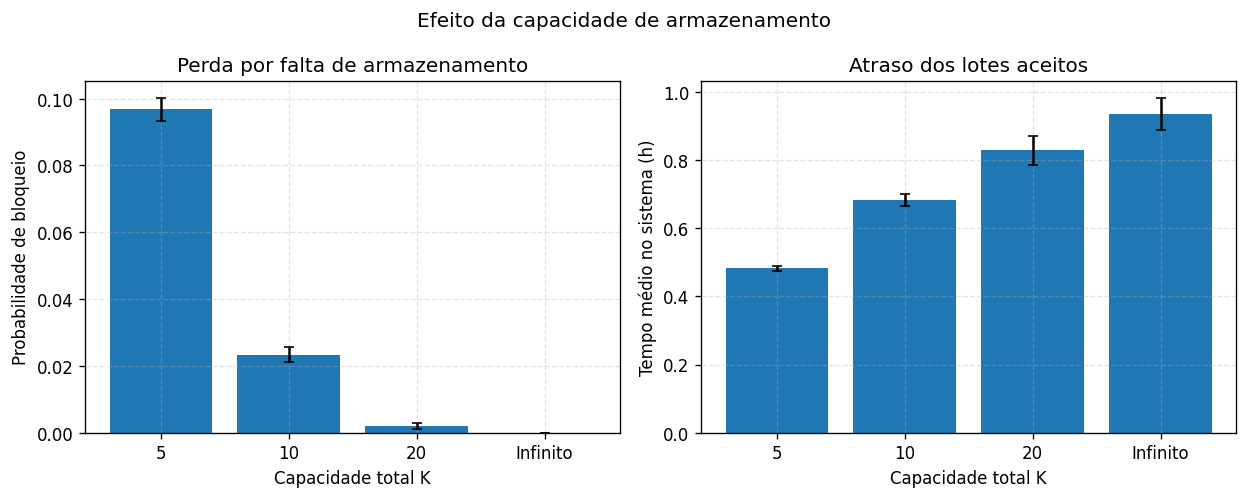

In [14]:
fig, eixos = plt.subplots(1, 2, figsize=(10.5, 4.2))
x = np.arange(len(tabela_buffers))
rotulos_buffer = tabela_buffers["Capacidade"]
eixos[0].bar(x, tabela_buffers["prob_bloqueio"],
             yerr=tabela_buffers["IC_prob_bloqueio"], capsize=3)
eixos[0].set_ylabel("Probabilidade de bloqueio")
eixos[0].set_title("Perda por falta de armazenamento")
eixos[1].bar(x, tabela_buffers["E_T"], yerr=tabela_buffers["IC_E_T"], capsize=3)
eixos[1].set_ylabel("Tempo médio no sistema (h)")
eixos[1].set_title("Atraso dos lotes aceitos")
for ax in eixos:
    ax.set_xticks(x)
    ax.set_xticklabels(rotulos_buffer)
    ax.set_xlabel("Capacidade total K")
fig.suptitle("Efeito da capacidade de armazenamento")
fig.tight_layout()
fig.savefig(FIG_DIR / "comparacao_buffers.png")
plt.show()

## 10. Síntese automática dos resultados

A célula abaixo imprime os valores centrais utilizados no artigo. Os números são lidos diretamente das tabelas produzidas, evitando transcrição manual.

In [15]:
base_en, base_en_ic = media_ic(rep_base, "E_N")
base_et, base_et_ic = media_ic(rep_base, "E_T")
base_a, base_a_ic = media_ic(rep_base, "disponibilidade")

print("CENÁRIO-BASE")
print(f"E[N] = {base_en:.4f} ± {base_en_ic:.4f}")
print(f"E[T] = {base_et:.4f} ± {base_et_ic:.4f} h")
print(f"Disponibilidade = {base_a:.5f} ± {base_a_ic:.5f}")
print(f"CTMC: E[N]={ctmc_base['E_N']:.4f}; E[T]={ctmc_base['E_T']:.4f} h")
print(f"Aproximação μ_eff: E[N]={aprx_base['E_N']:.4f}; E[T]={aprx_base['E_T']:.4f} h")
print()
print("COMPARAÇÃO DE FILAS")
print(tabela_filas[["Sistema", "E_N", "E_T", "utilizacao", "vazao"]].round(4).to_string(index=False))
print()
print("DISTRIBUIÇÕES")
print(tabela_distribuicoes[["Distribuição", "E_N", "E_T"]].round(4).to_string(index=False))
print()
print("BUFFERS")
print(tabela_buffers[["Capacidade", "E_N", "E_T", "prob_bloqueio", "vazao"]].round(5).to_string(index=False))

CENÁRIO-BASE
E[N] = 3.8859 ± 0.4275
E[T] = 0.9282 ± 0.0968 h
Disponibilidade = 0.90941 ± 0.00397
CTMC: E[N]=3.9012; E[T]=0.9289 h
Aproximação μ_eff: E[N]=3.3478; E[T]=0.7971 h

COMPARAÇÃO DE FILAS
         Sistema    E_N    E_T  utilizacao  vazao
M/M/1 sem falhas 2.2884 0.5460      0.6955 4.1902
M/M/1 com falhas 3.9703 0.9403      0.7031 4.2218
M/M/2 sem falhas 0.7947 0.1902      0.3488 4.1779

DISTRIBUIÇÕES
    Distribuição    E_N    E_T
  Determinístico 2.6604 0.6366
        Erlang-2 3.2744 0.7821
     Exponencial 3.7148 0.8887
Hiperexponencial 4.6137 1.1032

BUFFERS
Capacidade     E_N     E_T  prob_bloqueio   vazao
         5 1.82897 0.48282        0.09679 3.78840
        10 2.78796 0.68257        0.02334 4.08345
        20 3.44704 0.82843        0.00190 4.16045
  Infinito 3.93889 0.93493        0.00000 4.21125


## 11. Observações para reprodução

- O gerador `numpy.random.default_rng` é inicializado com sementes independentes obtidas por `SeedSequence`.
- As tabelas são salvas na pasta `tabelas_fila`.
- As figuras são salvas na pasta `figuras_fila` em 300 dpi.
- A janela de coleta começa somente após o período de aquecimento.
- Os intervalos de confiança usam a distribuição t de Student e o desvio-padrão amostral (`ddof=1`).
- O simulador mantém a tarefa interrompida no servidor e conserva seu tempo restante.